# C10.5 Cyclic Processes and Heat Engines
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Why this section matters

In previous sections, we studied:

- Thermodynamic states  
- Special processes  
- Heat capacities  
- Work as area on a PV diagram  

Now we bring these ideas together.

> A heat engine operates by moving through a **cycle** of thermodynamic states.

Cyclic processes are central to:

- Power plants  
- Internal combustion engines  
- Refrigerators  
- Atmospheric circulation  

Understanding cycles allows us to see how heat can be partially converted into mechanical work.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## 1. What Is a Cyclic Process?

A **cyclic process** occurs when a system:

- Starts in some state  
- Undergoes several changes  
- Returns to its original state  

Graphically, on a PV diagram, a cycle forms a **closed loop**.

Because the initial and final states are identical:

$$
\Delta U = 0
$$

This is a direct consequence of internal energy being a state function.

---

## 2. Energy Accounting in a Cycle

From the First Law:

$$
\Delta U = Q - W
$$

For a complete cycle:

$$
\Delta U = 0
$$

Therefore:

$$
Q_{\text{net}} = W_{\text{net}}
$$

The net heat added to the system equals the net work done by the system.

This is one of the most important results in thermodynamics.

---

## 3. Work from a PV Diagram

For a cyclic process:

- The net work equals the **area enclosed** by the loop.
- Clockwise cycle → $W_{\text{net}} > 0$
- Counterclockwise cycle → $W_{\text{net}} < 0$

This geometric interpretation connects directly to C10.2.

A heat engine corresponds to a **clockwise cycle** on a PV diagram.




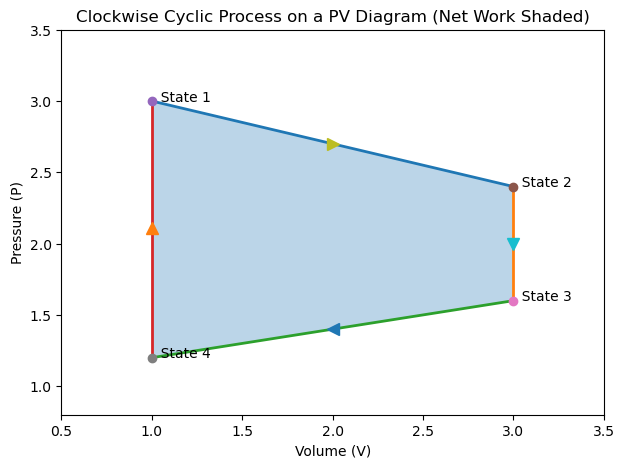

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# -------------------------------------------------------
# Define the cycle by specifying two curve functions
# (top and bottom) over the same volume interval.
# States are then taken from the curve endpoints so
# all four segments connect perfectly.
# -------------------------------------------------------

V1 = 1.0
V2 = 3.0
V = np.linspace(V1, V2, 400)

# Top path (1 -> 2): gently decreasing with V
P_top = 3.0 - 0.3*(V - V1)

# Bottom path (3 -> 4): slightly increasing with V
P_bottom = 1.2 + 0.2*(V - V1)

# Define states from endpoints (guarantees alignment)
P1 = P_top[0]      # at V1
P2 = P_top[-1]     # at V2
P3 = P_bottom[-1]  # at V2
P4 = P_bottom[0]   # at V1

# States
state1 = (V1, P1)
state2 = (V2, P2)
state3 = (V2, P3)
state4 = (V1, P4)

# Right vertical (2 -> 3)
P_right = np.linspace(P2, P3, 120)
V_right = np.full_like(P_right, V2)

# Left vertical (4 -> 1)
P_left = np.linspace(P4, P1, 120)
V_left = np.full_like(P_left, V1)

# -------------------------------------------------------
# Plot the four segments
# -------------------------------------------------------
plt.plot(V, P_top, linewidth=2)                # 1 -> 2
plt.plot(V_right, P_right, linewidth=2)        # 2 -> 3
plt.plot(V[::-1], P_bottom[::-1], linewidth=2) # 3 -> 4 (reverse direction)
plt.plot(V_left, P_left, linewidth=2)          # 4 -> 1

# Shade net work area (area enclosed)
plt.fill_between(V, P_bottom, P_top, alpha=0.3)

# -------------------------------------------------------
# Mark and label states
# -------------------------------------------------------
states = [("State 1", *state1), ("State 2", *state2), ("State 3", *state3), ("State 4", *state4)]
for label, x, y in states:
    plt.plot(x, y, marker='o')
    plt.text(x, y, "  " + label)

# Direction markers embedded in each segment
mid = len(V)//2
plt.plot(V[mid], P_top[mid], marker='>', markersize=9)              # 1->2
plt.plot(V_right[60], P_right[60], marker='v', markersize=9)        # 2->3
plt.plot(V[mid], P_bottom[mid], marker='<', markersize=9)           # 3->4 (moving left)
plt.plot(V_left[60], P_left[60], marker='^', markersize=9)          # 4->1

# Labels and view
plt.xlabel("Volume (V)")
plt.ylabel("Pressure (P)")
plt.title("Clockwise Cyclic Process on a PV Diagram (Net Work Shaded)")
plt.xlim(0.5, 3.5)
plt.ylim(0.8, 3.5)

plt.show()

---

## 4. Heat Engine Concept

A **heat engine** operates by:

1. Absorbing heat $Q_H$ from a high-temperature reservoir.
2. Converting part of that heat into work.
3. Releasing remaining heat $Q_C$ to a low-temperature reservoir.

Energy conservation requires:

$$
Q_H = W_{\text{out}} + Q_C
$$

Since:

$$
W_{\text{out}} = Q_H - Q_C
$$

Not all absorbed heat becomes work.

---

## 5. Efficiency of a Heat Engine

The **thermal efficiency** of an engine measures how effectively it converts absorbed heat into useful work.

By definition:

$$
e = \frac{W_{\text{out}}}{Q_H}
$$

where:

- $W_{\text{out}}$ is the work produced per cycle  
- $Q_H$ is the heat absorbed from the hot reservoir  

For a cyclic process:

$$
\Delta U = 0
$$

so from the First Law:

$$
W_{\text{out}} = Q_H - Q_C.
$$

Substituting:

$$
e = \frac{Q_H - Q_C}{Q_H}
= 1 - \frac{Q_C}{Q_H}.
$$

---

### Why Efficiency Is Always Less Than 1

Because $Q_C$ must be positive for any real engine,

$$
e = 1 - \frac{Q_C}{Q_H} < 1.
$$

No real heat engine converts all absorbed heat into work.

A cold reservoir is required by the Second Law of Thermodynamics.

---

### The Carnot Engine — The Maximum Possible Efficiency

In the 1820s, **Sadi Carnot** studied the question:

> What is the greatest efficiency any heat engine could possibly have?

He considered an idealized engine that:

- Operates reversibly  
- Has no friction  
- Transfers heat infinitely slowly  
- Produces no entropy  

This ideal engine is called the **Carnot engine**.

Carnot showed that:

> No engine operating between the same two temperatures can be more efficient than a Carnot engine.

Its efficiency depends **only on temperature**, not on the working substance.

The maximum possible efficiency is:

$$
e_{\text{Carnot}} = 1 - \frac{T_C}{T_H}
$$

where:

- $T_H$ is the temperature of the hot reservoir (in Kelvin)
- $T_C$ is the temperature of the cold reservoir (in Kelvin)

---

### What This Means Physically

1. Efficiency depends only on temperature difference.
2. Larger temperature differences allow higher maximum efficiency.
3. No engine can exceed this limit.
4. Even a perfect reversible engine cannot reach 100% efficiency unless:

   $$
   T_C = 0\ \text{K}.
   $$

Since absolute zero cannot be reached, perfect efficiency is impossible.

---

### Why Carnot Matters in Phase C

At this stage, we do not yet derive the Carnot result from entropy.

Instead, we use it as a **physical boundary condition**:

- It defines the theoretical upper limit.
- Real engines always have efficiencies below the Carnot value.
- The Carnot result explains why engineers seek very high $T_H$ and very low $T_C$.

The full derivation will come later when we formally connect efficiency to entropy.

---

### Conceptual Summary

For any heat engine:

$$
0 < e < e_{\text{Carnot}} < 1.
$$

Efficiency is limited not by engineering, but by the fundamental laws of thermodynamics.

---

## 6. Physical Interpretation

A heat engine requires:

- A temperature difference.
- Continuous cycling between states.
- Heat flow from hot to cold.

Without a temperature difference, no net work can be produced.

This introduces a deeper principle:

> There are fundamental limits to how efficiently heat can be converted into work.

We will explore those limits more formally in Phase B.

---

## 7. Refrigerator and Heat Pump (Brief Comparison)

If the cycle runs in the opposite direction:

- Work is supplied to the system.
- Heat is removed from a cold reservoir.
- Heat is delivered to a hot reservoir.

This is the operating principle of:

- Refrigerators  
- Air conditioners  
- Heat pumps  

The direction of the cycle determines whether the device produces work or consumes work.

---

## Conceptual Checkpoints

You should now be able to answer:

- Why is $\Delta U = 0$ in a cyclic process?
- Why does the area inside a PV loop represent net work?
- Why must some heat always be rejected?
- Why does a heat engine require two reservoirs?

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Preparation for Phase B

In Phase C, we have developed:

- Geometric reasoning  
- Energy accounting  
- Algebraic efficiency  

In Phase B, we will:

- Derive limits on efficiency.
- Introduce entropy formally.
- Develop the Carnot cycle mathematically.

Cyclic engines are the bridge between energy conservation and the Second Law of Thermodynamics.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">